# Modifying the Architecture by Adding more Layers and Neurons

Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.9115 - loss: 0.3028 - val_accuracy: 0.9602 - val_loss: 0.1399
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9665 - loss: 0.1096 - val_accuracy: 0.9701 - val_loss: 0.1010
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9769 - loss: 0.0735 - val_accuracy: 0.9743 - val_loss: 0.0915
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9840 - loss: 0.0508 - val_accuracy: 0.9719 - val_loss: 0.0929
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9883 - loss: 0.0380 - val_accuracy: 0.9739 - val_loss: 0.0876
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9767 - loss: 0.0769
Test Accuracy: 0.9767000079154968
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


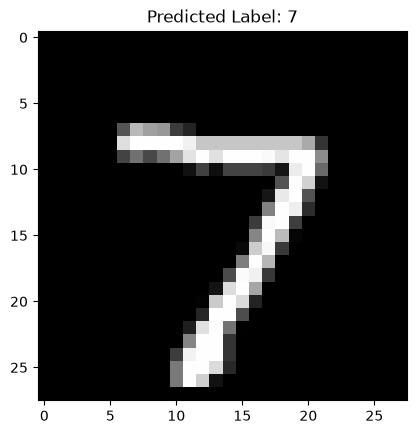

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

# Load Dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Normalize
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1).astype('float32') / 255
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1).astype('float32') / 255

# Improved Model
model = Sequential()

model.add(Flatten(input_shape=(28,28,1)))

model.add(Dense(256, activation='relu'))
model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))

model.add(Dense(10, activation='softmax'))

# Compile
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.2
)

# Evaluate
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", test_accuracy)

predictions = model.predict(X_test)
plt.imshow(X_test[0].reshape(28,28), cmap='gray')
plt.title(f"Predicted Label: {np.argmax(predictions[0])}")
plt.show()